<a href="https://colab.research.google.com/github/bhar007-neel/Deep-Learning-Computer-Vision-project--Pneumonia-Classifier/blob/main/Deep_Learning_Computer_Vision_project_Pneumonia_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/Colab Notebooks/"

 data.zip  'Machine Learning Project- Pneumonia Classifier.ipynb'


In [3]:
!unzip -q -o "/content/drive/MyDrive/Colab Notebooks/data.zip" -d /content/

In [5]:
!ls /content/
!ls /content/data
!ls /content/data/train

data  drive  sample_data
chest_xray  __MACOSX  test  train  val
NORMAL	PNEUMONIA


In [6]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [7]:
!pip install -q torch torchvision scikit-learn pillow

In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import accuracy_score
from PIL import Image

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
class PneumoniaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # Save the folder path and image transformations
        self.root_dir = root_dir
        self.transform = transform

        # These lists will store:
        # 1. paths to all image files
        # 2. numeric labels for each image
        self.image_paths = []
        self.labels = []

        # Go through both class folders
        # NORMAL = 0
        # PNEUMONIA = 1
        for label in ["NORMAL", "PNEUMONIA"]:
            class_dir = os.path.join(root_dir, label)

            # Go through every file in that class folder
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)

                # Save image path
                self.image_paths.append(img_path)

                # Save numeric label
                if label == "NORMAL":
                    self.labels.append(0)
                else:
                    self.labels.append(1)

    def __len__(self):
        # Return total number of images
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Get image path and label using index
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Open image using PIL and convert it to RGB
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Return processed image and label
        return image, label

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize every image to 224x224
    transforms.ToTensor(),           # Convert image to PyTorch tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Standard mean values for pretrained ResNet
        std=[0.229, 0.224, 0.225]    # Standard std values for pretrained ResNet
    )
])


In [12]:
train_dataset = PneumoniaDataset(root_dir="/content/data/train", transform=transform)
val_dataset = PneumoniaDataset(root_dir="/content/data/val", transform=transform)
test_dataset = PneumoniaDataset(root_dir="/content/data/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 5216
Val samples: 16
Test samples: 624


In [13]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the last layer because we only need 2 output classes
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to GPU or CPU
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

In [15]:
for epoch in range(num_epochs):
    model.train()  # training mode
    running_loss = 0.0

    for images, labels in train_loader:
        # Move images and labels to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss for this batch
        running_loss += loss.item()

    # Average loss for this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.1151
Epoch [2/10], Loss: 0.0656
Epoch [3/10], Loss: 0.0526
Epoch [4/10], Loss: 0.0398
Epoch [5/10], Loss: 0.0330
Epoch [6/10], Loss: 0.0357
Epoch [7/10], Loss: 0.0248
Epoch [8/10], Loss: 0.0216
Epoch [9/10], Loss: 0.0108
Epoch [10/10], Loss: 0.0150


In [17]:
model.eval()

test_labels = []
test_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Save true labels and predicted labels
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

# Calculate test accuracy
test_accuracy = accuracy_score(test_labels, test_preds)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.8173076923076923


In [18]:
torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/pneumonia_classifier.pth")
print("Model saved successfully as pneumonia_classifier.pth")

Model saved successfully as pneumonia_classifier.pth


In [19]:
import torch.nn.functional as F

outputs = model(images)
probs = F.softmax(outputs, dim=1)

confidence, preds = torch.max(probs, 1)

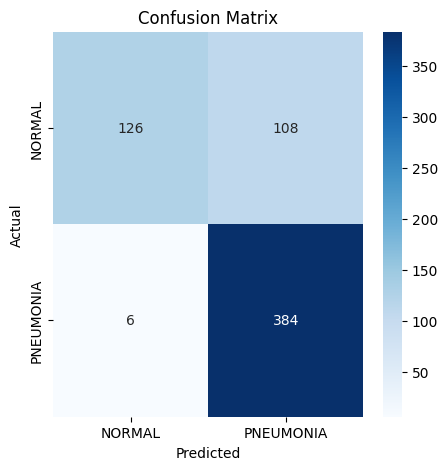

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
losses = []

In [22]:
losses.append(avg_loss)

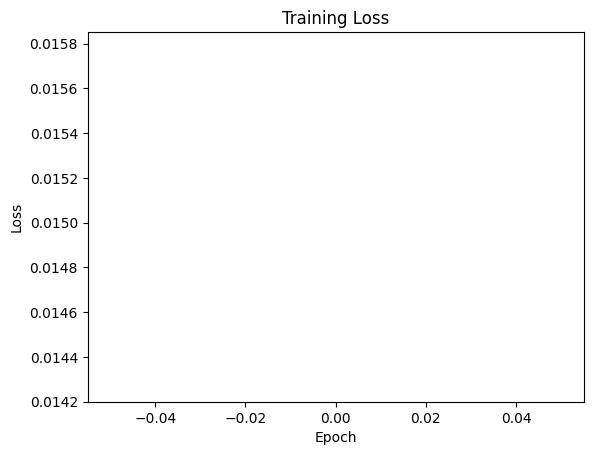

In [23]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

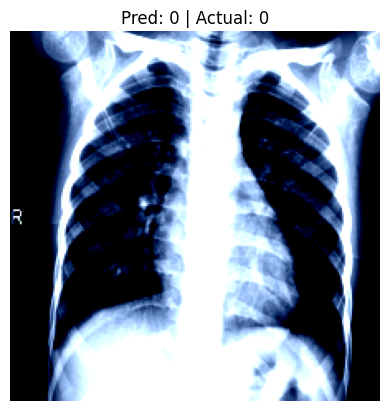

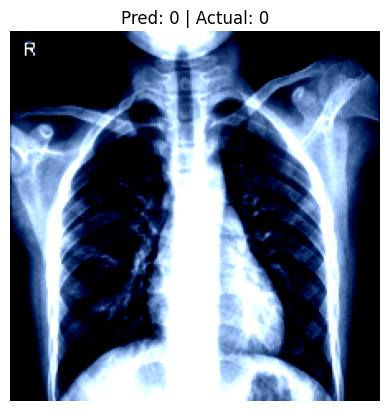

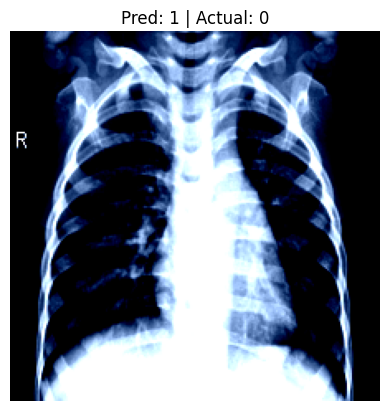

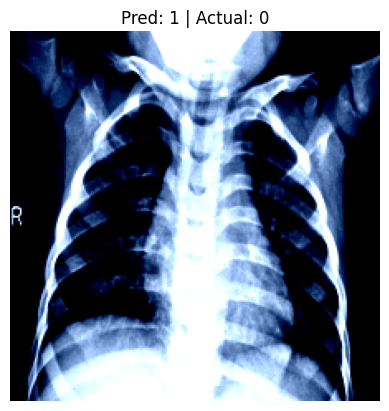

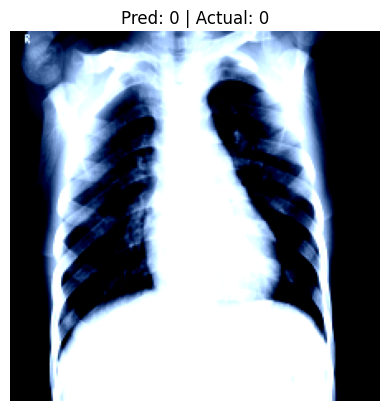

In [24]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

for i in range(5):
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Pred: {preds[i].item()} | Actual: {labels[i].item()}")
    plt.axis('off')
    plt.show()

In [25]:
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/pneumonia_classifier.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/pneumonia_classifier.pth", map_location=device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [29]:
def predict_image(img_path, model, transform):
    model.eval()

    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    outputs = model(image)
    _, pred = torch.max(outputs, 1)

    return "PNEUMONIA" if pred.item() == 1 else "NORMAL"

In [30]:
import os

normal_images = os.listdir("/content/data/test/NORMAL")
print(normal_images[:5])

['NORMAL2-IM-0380-0001.jpeg', 'IM-0011-0001.jpeg', 'NORMAL2-IM-0305-0001.jpeg', 'NORMAL2-IM-0331-0001.jpeg', 'NORMAL2-IM-0171-0001.jpeg']


In [31]:
import os

normal_images = os.listdir("/content/data/test/NORMAL")
print(normal_images[:5])

['NORMAL2-IM-0380-0001.jpeg', 'IM-0011-0001.jpeg', 'NORMAL2-IM-0305-0001.jpeg', 'NORMAL2-IM-0331-0001.jpeg', 'NORMAL2-IM-0171-0001.jpeg']


In [33]:
test_img_path = "/content/data/test/NORMAL/" + normal_images[0]
prediction = predict_image(test_img_path, model, transform)

print("Image path:", test_img_path)
print("Prediction:", prediction)

Image path: /content/data/test/NORMAL/NORMAL2-IM-0380-0001.jpeg
Prediction: NORMAL


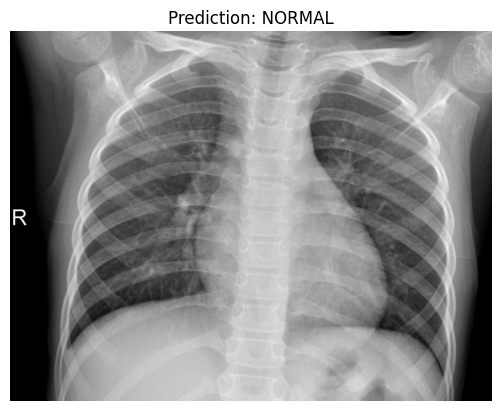

In [34]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(test_img_path)
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {prediction}")
plt.axis("off")
plt.show()

Image path: /content/data/test/NORMAL/NORMAL2-IM-0380-0001.jpeg
Prediction: NORMAL


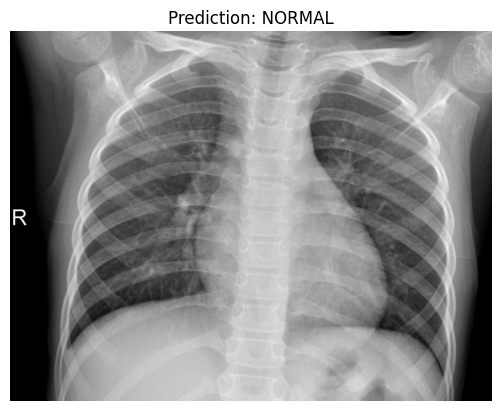

In [35]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def predict_image(img_path, model, transform, device):
    model.eval()

    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return "PNEUMONIA" if pred.item() == 1 else "NORMAL"


# pick one sample image from NORMAL folder
normal_images = os.listdir("/content/data/test/NORMAL")
test_img_path = "/content/data/test/NORMAL/" + normal_images[0]

# predict
prediction = predict_image(test_img_path, model, transform, device)

# print result
print("Image path:", test_img_path)
print("Prediction:", prediction)

# display image
img = Image.open(test_img_path)
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {prediction}")
plt.axis("off")
plt.show()

In [36]:
import torch.nn.functional as F

def predict_image_with_confidence(img_path, model, transform, device):
    model.eval()

    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    label = "PNEUMONIA" if pred.item() == 1 else "NORMAL"
    return label, confidence.item()

In [37]:
label, confidence = predict_image_with_confidence(test_img_path, model, transform, device)
print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: NORMAL
Confidence: 98.78 %
